In [40]:
import pandas as pd

In [41]:
url = "https://docs.google.com/spreadsheets/d/1AjcqmM5kkCniTcL2gINvpiub-vefKA0nZR2Ln3eUFL8/export?format=csv"

df = pd.read_csv(url)

In [42]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [43]:
#Information required before starting the analysis
print("Info about the dataset:")
df.info()

Info about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [44]:
df['Review Date'] = pd.to_datetime(df['Review Date'])

In [45]:
print("\nInfo about the data itself:")
df.describe()


Info about the data itself:


,Ratings,Review Date
count,196727.000000,196727
mean,4.503535,2024-03-25 22:03:05.784020736
min,1.000000,2023-07-25 15:01:35
25%,5.000000,2024-01-06 09:47:07
50%,5.000000,2024-04-22 20:53:30
75%,5.000000,2024-06-24 16:43:04.500000
max,5.000000,2024-08-23 19:30:05
std,1.083004,NaN


In [46]:
print("\nNo. of duplicate rows in the dataset")
df.duplicated().sum()


No. of duplicate rows in the dataset


np.int64(2511)

In [47]:
df = df.dropna(subset=['Review'])

In [48]:
print("\nNo. of null values in the dataset")
df.isnull().sum()


No. of null values in the dataset


Review Id      0
Review         0
Ratings        0
Review Date    0
dtype: int64

In [49]:
df['Ratings'].value_counts().sort_index()

Ratings
1     12080
2      3375
3      8157
4     22897
5    150212
Name: count, dtype: int64

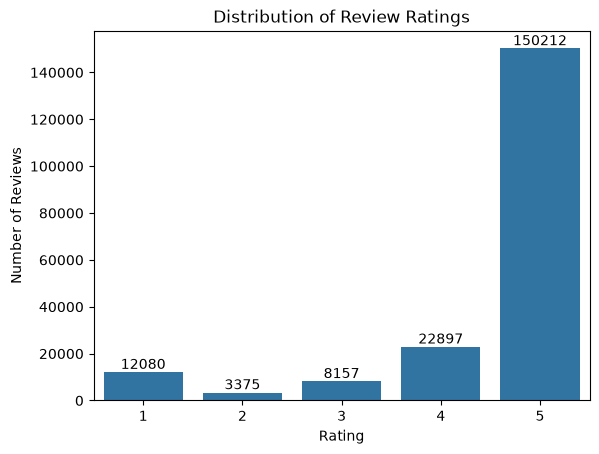

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

ax=sns.countplot(x='Ratings', data=df)

plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

ax.bar_label(ax.containers[0], fmt='%d')

plt.show()

In [51]:
print("Earliest review:", df['Review Date'].min())
print("Latest review:", df['Review Date'].max())

Earliest review: 2023-07-25 15:01:35
Latest review: 2024-08-23 19:30:05


In [52]:
monthly_reviews = df['Review Date'].dt.to_period('M').value_counts().sort_index()

monthly_reviews = monthly_reviews.reset_index()

monthly_reviews

,Review Date,count
0,2023-07,8283
1,2023-08,6801
2,2023-09,7593
3,2023-10,5824
4,2023-11,8719
5,2023-12,10375
6,2024-01,9313
7,2024-02,8748
8,2024-03,15173
9,2024-04,23737


In [53]:
monthly_reviews = monthly_reviews.rename(columns={'count': 'Review Count'})

monthly_reviews['Review Date'] = monthly_reviews['Review Date'].dt.to_timestamp()

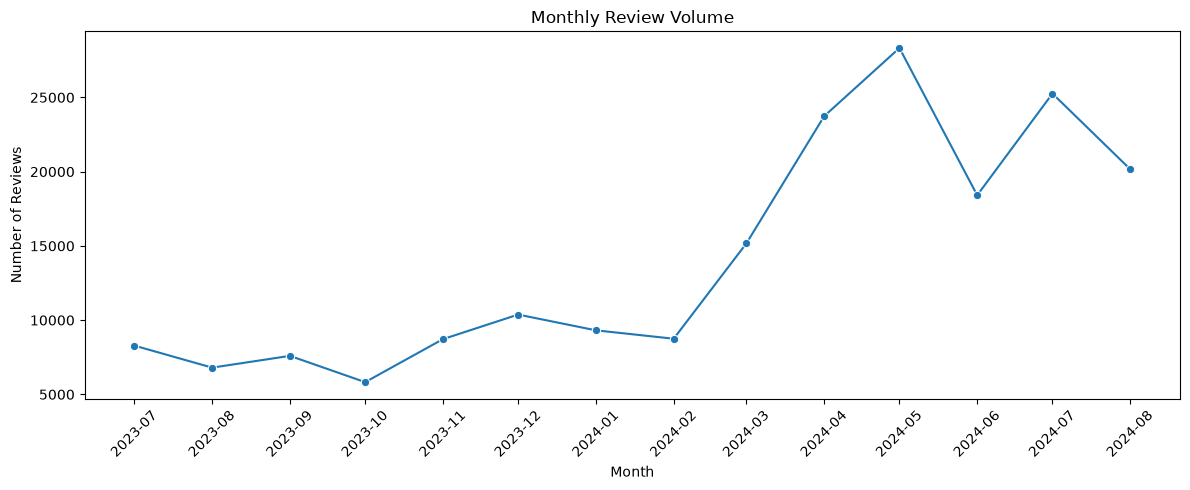

In [54]:
import matplotlib.dates as mdates
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_reviews,
    x='Review Date',
    y='Review Count',
    marker='o'
)

plt.title('Monthly Review Volume')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(monthly_reviews['Review Date'], rotation=45)
plt.tight_layout()

plt.show()

In [55]:
df = df.drop_duplicates()

#percentage of each rating
df['Ratings'].value_counts(normalize=True).sort_index() * 100

Ratings
1     6.159827
2     1.722877
3     4.142938
4    11.638433
5    76.335925
Name: proportion, dtype: float64

In [56]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [57]:
sia = SentimentIntensityAnalyzer()

In [58]:
test_review = df['Review'].iloc[0]

print(test_review)
print(sia.polarity_scores(test_review))

good
{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.4404}


In [59]:
df['Sentiment Score'] = df['Review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [60]:
df[['Review', 'Sentiment Score']].head(10)

,Review,Sentiment Score
0,good,0.4404
1,good,0.4404
2,nice app,0.4215
3,"nice, ig",0.4215
4,"this is a great app, the bot is so accurate to...",0.9427
5,so nice app,0.4754
6,"just love this app, or guy",0.6369
7,great app,0.6249
8,Very impressive,0.5563
9,helps with coding a lot this ai is great for e...,0.7717


In [61]:
df['Sentiment'] = df['Sentiment Score'].apply(
    lambda x: 'Positive' if x >= 0.05
    else 'Negative' if x <= -0.05
    else 'Neutral'
)

df['Sentiment'].value_counts()

Sentiment
Positive    148610
Neutral      34905
Negative     10695
Name: count, dtype: int64

In [62]:
df['Sentiment'].value_counts(normalize=True) * 100

Sentiment
Positive    76.520262
Neutral     17.972813
Negative     5.506925
Name: proportion, dtype: float64

In [63]:
rating_sentiment_pct = pd.crosstab(
    df['Ratings'],
    df['Sentiment'],
    normalize='index'
) * 100

rating_sentiment_pct

Sentiment,Negative,Neutral,Positive
Ratings,,,
1,39.020313,32.032099,28.947588
2,30.215182,25.552899,44.231919
3,15.224957,21.675367,63.099677
4,6.074415,15.382914,78.542671
5,1.631007,16.861155,81.507838


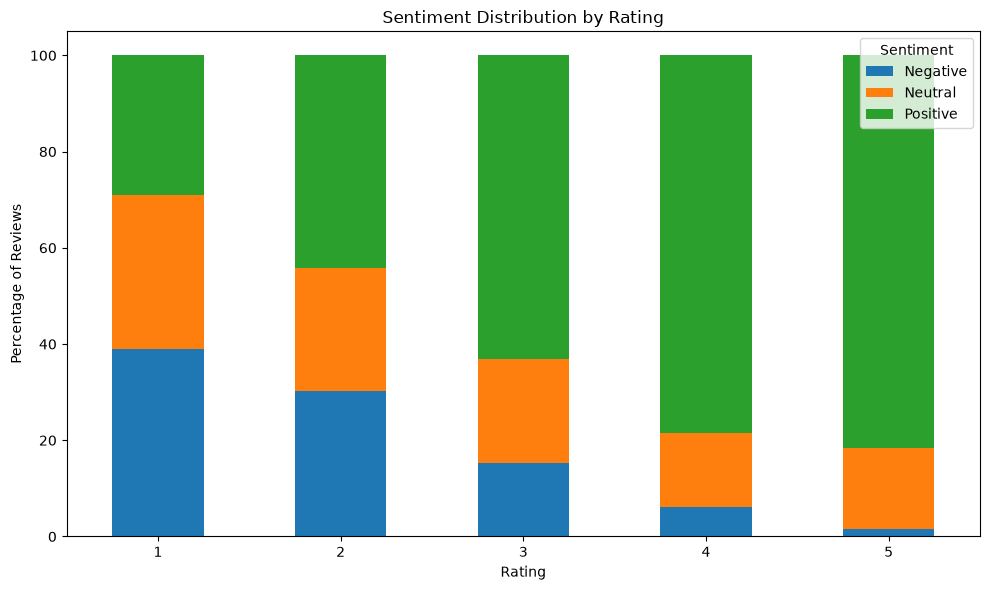

In [64]:
rating_sentiment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [65]:
negative_reviews = df.loc[df['Sentiment'] == 'Negative', 'Review']

negative_text = ' '.join(negative_reviews)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [66]:
import re
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

words = re.findall(r"\b[a-zA-Z']+\b", negative_text.lower())

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

word_counts = Counter(filtered_words)

word_counts.most_common(20)

[('app', 3347),
 ('good', 1164),
 ('wrong', 1027),
 ('chatgpt', 927),
 ('error', 920),
 ("can't", 877),
 ('bad', 870),
 ('problem', 867),
 ('use', 825),
 ('time', 807),
 ('even', 733),
 ('chat', 712),
 ('answer', 711),
 ('like', 645),
 ('information', 605),
 ('answers', 542),
 ('give', 534),
 ('please', 529),
 ('gpt', 518),
 ('sometimes', 514)]

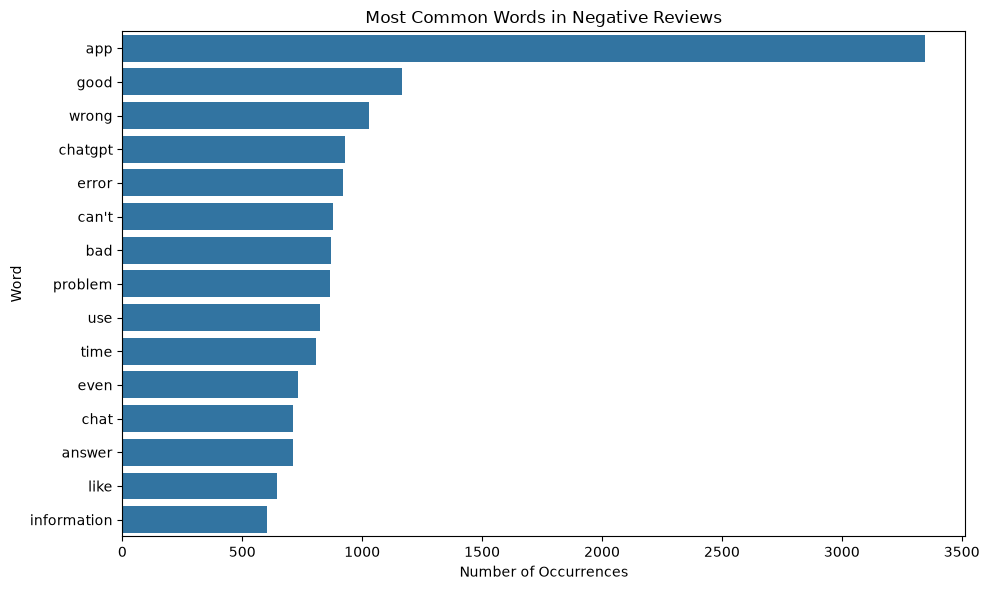

In [67]:
top_words = pd.DataFrame(
    word_counts.most_common(15),
    columns=['Word', 'Count']
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x='Count',
    y='Word'
)

plt.title('Most Common Words in Negative Reviews')
plt.xlabel('Number of Occurrences')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

In [68]:
positive_reviews = df.loc[df['Sentiment'] == 'Positive', 'Review']

positive_text = ' '.join(positive_reviews)

In [69]:
positive_words = re.findall(
    r"\b[a-zA-Z']+\b",
    positive_text.lower()
)

positive_stop_words = stop_words.union({
    'app',
    'chatgpt',
    'chat',
    'use'
})

filtered_positive_words = [
    word for word in positive_words
    if word not in stop_words and len(word) > 2
]

In [70]:
from wordcloud import WordCloud

In [71]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(' '.join(filtered_positive_words))

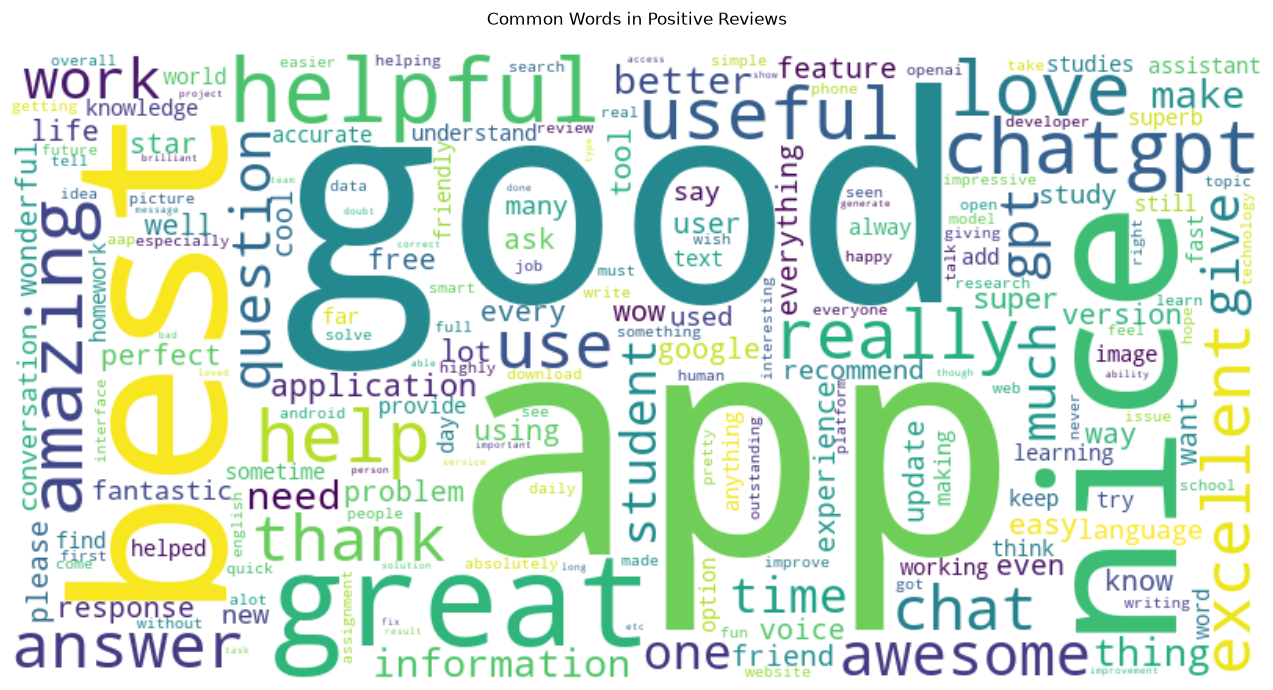

In [73]:
plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title('Common Words in Positive Reviews\n')

plt.tight_layout()
plt.show()